In [128]:
%matplotlib inline
import numpy as np
import os
import pandas as pd
import glob
import japanize_matplotlib
import seaborn as sns
from scipy import stats
import itertools
import decimal

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap


def my_gkf(group, n_splits, random_state):
    unique_group = np.unique(group)
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=True)
    for t,v in kf.split(unique_group, unique_group):
        t_group = unique_group[t]
        v_group = unique_group[v]
        yield np.where(np.isin(group, t_group))[0], np.where(np.isin(group, v_group))[0]
        
def load_data(Day: int):
    if Day == 38:
        df_feature= pd.read_csv("../data/fftfeature/feature38.csv")
    elif Day == 34:
        df_feature= pd.read_csv("../data/fftfeature/feature34.csv")
    elif Day == 31:
        df_feature= pd.read_csv("../data/fftfeature/feature31.csv")
    elif Day == 27:
        df_feature= pd.read_csv("../data/fftfeature/feature27.csv")
    elif Day == 24:
        df_feature= pd.read_csv("../data/fftfeature/feature24.csv")
    elif Day == 20:
        df_feature= pd.read_csv("../data/fftfeature/feature20.csv")
    elif Day == 17:
        df_feature= pd.read_csv("../data/fftfeature/feature17.csv")
    elif Day == 14:
        df_feature= pd.read_csv("../data/fftfeature/feature14.csv")
    else:
        df_feature= pd.read_csv("../data/fftfeature/feature.csv")
    return df_feature

def extract_data(df_feature):
    df = df_feature
    df["FLAG"] = df_feature["score"] > 20
    df = df.sample(frac=1, ignore_index=True, random_state=seed)
    df_20over = df[df["FLAG"] == True].iloc[:,1:101]
    
    df = df_feature
    df["FLAG"] = df_feature["score"] < 10
    df = df.sample(frac=1, ignore_index=True, random_state=seed)
    df_10under = df[df["FLAG"] == True].iloc[:,1:101]
    
    df = df_feature
    df["FLAG"] = (df_feature["score"] <= 20) & (df_feature["score"] >= 10)
    df = df.sample(frac=1, ignore_index=True, random_state=seed)
    df_10_20 = df[df["FLAG"] == True].iloc[:,1:101]
    
    df_20over["class"]="20over"
    df_10under["class"]="10under"
    df_10_20["class"]="between10~20"
    df_concat = pd.concat([df_20over,df_10_20])
    df_concat = pd.concat([df_concat, df_10under])
    
    return df_concat

def plotbyclass(df, dim, title="", ):
    plt.figure(figsize=(12,8))
    sns.set(font_scale = 2)

    p = sns.boxplot(data=df, x='class', y=dim)
    p = sns.swarmplot(data=df, x='class', y=dim, color="black")
    #p = sns.violinplot(data=results20, x='Day', y='AUC')
    #p.set_ylim(0.0, 1.0)
    p.set_title(title)
    plt.savefig("./周波数/"+ title+".png")
    
def plotbyday(df, dim, title=""):
    plt.figure(figsize=(12,8))
    sns.set(font_scale = 2)

    p = sns.boxplot(data=df, x='day', y=dim)
    p = sns.swarmplot(data=df, x='day', y=dim, color="black")
    #p = sns.violinplot(data=results20, x='Day', y='AUC')
    #p.set_ylim(0.0, 1.0)
    p.set_title(title)
    plt.savefig("./周波数/"+ title+".png")
    
def mannwhitneyu(df, dim):
    decimal.getcontext().prec = 3
    classes = np.unique(df["class"].values)
    for pair in itertools.combinations(lis, 2):
        A = df[df["class"]==pair[0]][dim].values
        B = df[df["class"]==pair[1]][dim].values
        p = stats.mannwhitneyu(A, B, alternative='two-sided')[1]
        p = decimal.Decimal(p)
        print(pair)
        print("pvalue=",+p)

('10under', '20over')
pvalue= 0.0193
('10under', 'between10~20')
pvalue= 0.000394
('20over', 'between10~20')
pvalue= 3.08E-10
('10under', '20over')
pvalue= 0.197
('10under', 'between10~20')
pvalue= 4.26E-7
('20over', 'between10~20')
pvalue= 0.000118


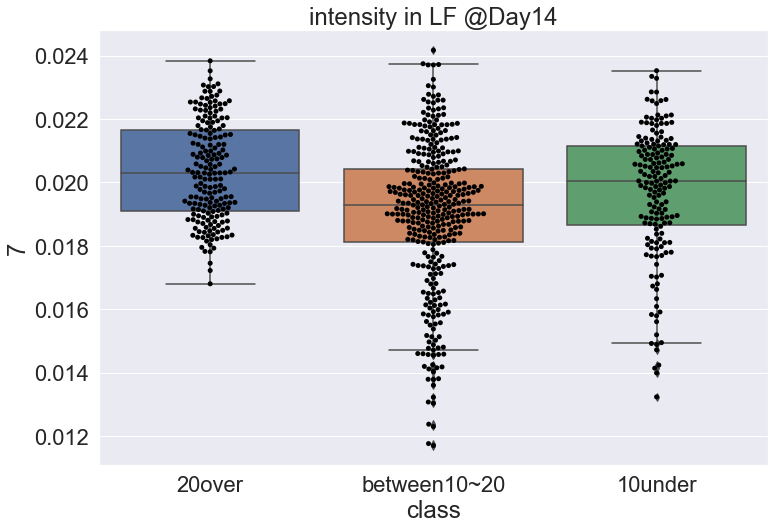

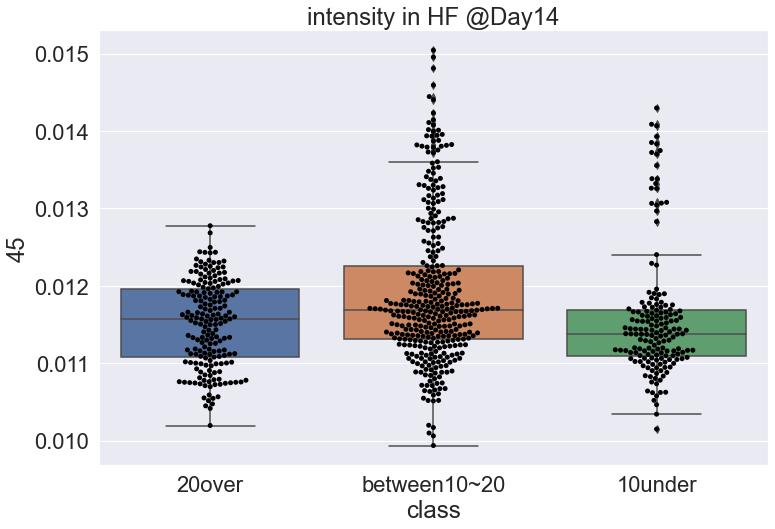

In [129]:
Day= 14
lf = "7" #or"45"
hf = "45"

df = load_data(Day)
df_features = extract_data(df)
mannwhitneyu(df_features,lf)
plotbyclass(df_features, dim=lf, title="intensity in LF @Day"+str(Day))
mannwhitneyu(df_features,hf)
plotbyclass(df_features, dim=hf, title="intensity in HF @Day"+str(Day))

/Users/taku/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 10.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/taku/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 22.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/taku/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 11.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/taku/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/taku/opt/anaconda3/lib/python3.7/site-packages/seabor

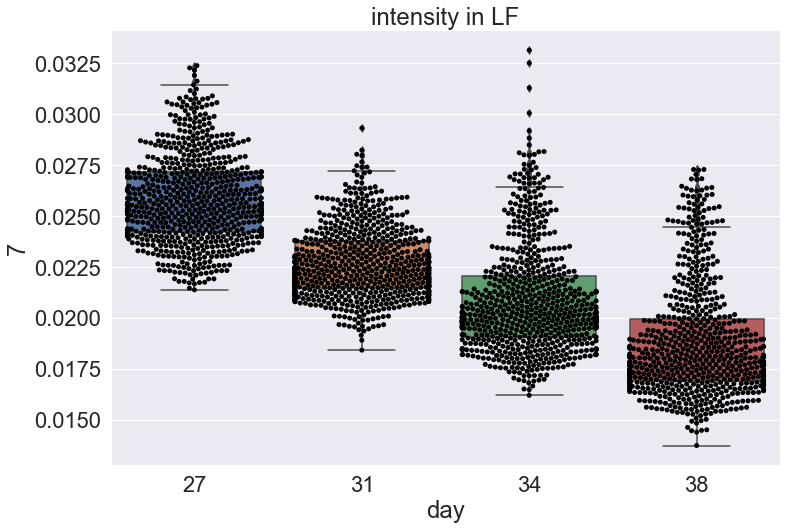

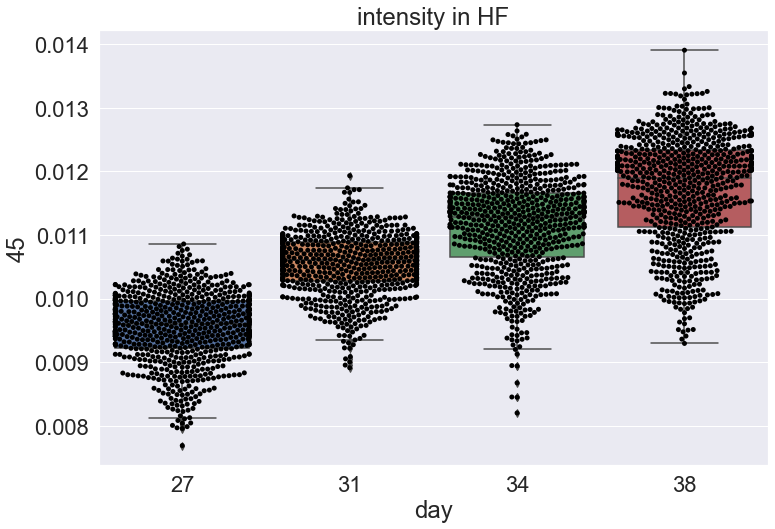

In [115]:
df = load_data(Day="nan")
plotbyday(df, dim=lf, title="intensity in LF")
plotbyday(df, dim=hf, title="intensity in HF")

## Recap: タスク精度

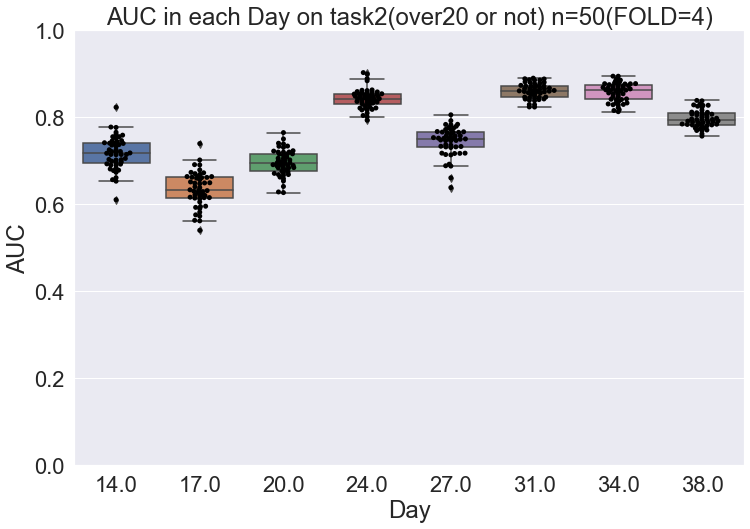

In [43]:
results20 = pd.read_csv("../data/220926results/"+"/task20over"+"/FOLD_4_n=50_result_bugfixed.csv")

plt.figure(figsize=(12,8))

sns.set(font_scale = 2)

results20["Day"].astype("int")
p = sns.boxplot(data=results20, x='Day', y='AUC')
p = sns.swarmplot(data=results20, x='Day', y='AUC', color="black")
#p = sns.violinplot(data=results20, x='Day', y='AUC')
p.set_ylim(0.0, 1.0)
p.set_title("AUC in each Day on task2(over20 or not) n=50(FOLD=4)")
plt.savefig("over20.svg")

In [44]:
results20

,Unnamed: 0,seed,accuracy,precision,recall,f1,AUC,TPR20,Day
0,0,100.0,0.764054,0.555846,0.492063,0.513588,0.741711,0.543651,14.0
1,1,100.0,0.686508,0.359929,0.293651,0.318432,0.629194,0.291667,17.0
2,2,100.0,0.724868,0.511905,0.361111,0.388908,0.723349,0.490079,20.0
3,3,100.0,0.806382,0.607077,0.658730,0.628341,0.821440,0.706349,24.0
4,4,100.0,0.776290,0.594907,0.458333,0.515979,0.771811,0.551587,27.0
...,...,...,...,...,...,...,...,...,...
395,395,149.0,0.784722,0.698418,0.595238,0.533919,0.829933,0.704365,24.0
396,396,149.0,0.730489,0.519056,0.430556,0.437009,0.713789,0.539683,27.0
397,397,149.0,0.772487,0.455682,0.466270,0.444099,0.829416,0.664683,31.0
398,398,149.0,0.825562,0.697025,0.644841,0.646596,0.854295,0.740079,34.0


## full spectre

/Users/taku/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  # Remove the CWD from sys.path while we load stuff.
/Users/taku/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  # This is added back by InteractiveShellApp.init_path()
/Users/taku/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:12: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  if s

Text(0.5, 1.0, 'Day20')

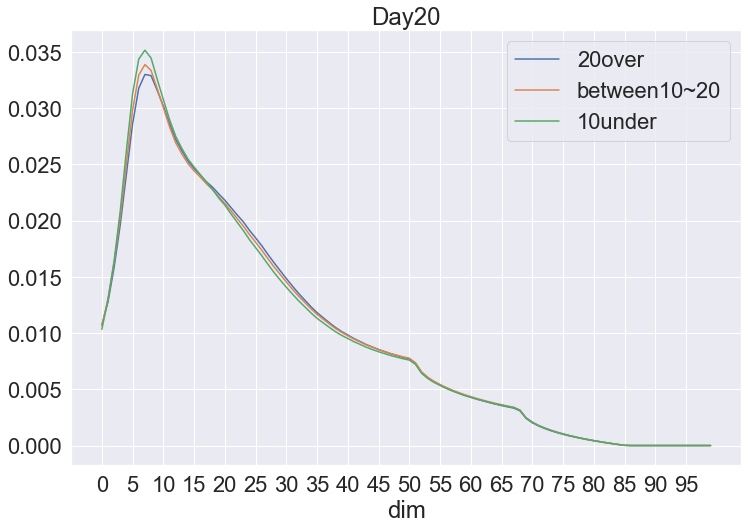

In [123]:
Day= 20


df = load_data(Day)
df = extract_data(df)
df_20over = df[df["class"]=="20over"]
df_10_20 = df[df["class"]=='between10~20']
df_10under = df[df["class"]=='10under']

mean20over = df_20over.mean(axis=0)
mean10_20 = df_10_20.mean(axis=0)
mean10under = df_10under.mean(axis=0)

plt.figure(figsize=(12,8))
plt.plot(mean20over)
plt.plot(mean10_20)
plt.plot(mean10under)
plt.legend(['20over', 'between10~20', '10under'])
plt.xlabel("dim")
plt.xticks(np.arange(0, 99, 5))
plt.title("Day"+str(Day))